# Environment Telemetry — AUTOPS Framework

Low-level satellite telemetry and environment diagnostics.
Battery SoC, data storage, mode transitions, anomaly events.

For **research-level architecture comparison**, see `analysis.ipynb`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib
import matplotlib.pyplot as plt
import pandas as pd

from src.orchestration.results_loader import load_experiment
from src.orchestration import plotting
importlib.reload(plotting)

plotting.apply_style()
%matplotlib inline

# RESULTS_PATH = ROOT / "data" / "results" / "eventsat_cen_sda_symb_hd_ah" / "results.json"
# RESULTS_PATH = ROOT / "data" / "results" / "eventsat_cen_sda_symb_hd_cg" / "results.json"
RESULTS_PATH = ROOT / "data" / "results" / "eventsat_cen_ooda_agnt_hd_ag" / "results.json"
raw, step_df, episode_df = load_experiment(RESULTS_PATH)

cfg_env = raw["config"]["environment"]
total_sec = cfg_env["timestep_seconds"] * cfg_env["max_steps"]

print(f"Experiment : {raw['experiment_id']}")
print(f"Episodes   : {raw['num_episodes']}")
print(f"Sim length : {cfg_env['max_steps']} steps x {cfg_env['timestep_seconds']}s = {total_sec/60:.0f} min")
print(f"Step DF    : {step_df.shape[0]} rows x {step_df.shape[1]} cols")

Experiment : eventsat_cen_ooda_agnt_hd_ag
Episodes   : 1
Sim length : 200 steps x 60s = 200 min
Step DF    : 200 rows x 28 cols


## 1. Dashboard

4-panel overview: battery, reward, mode distribution, episode summary.

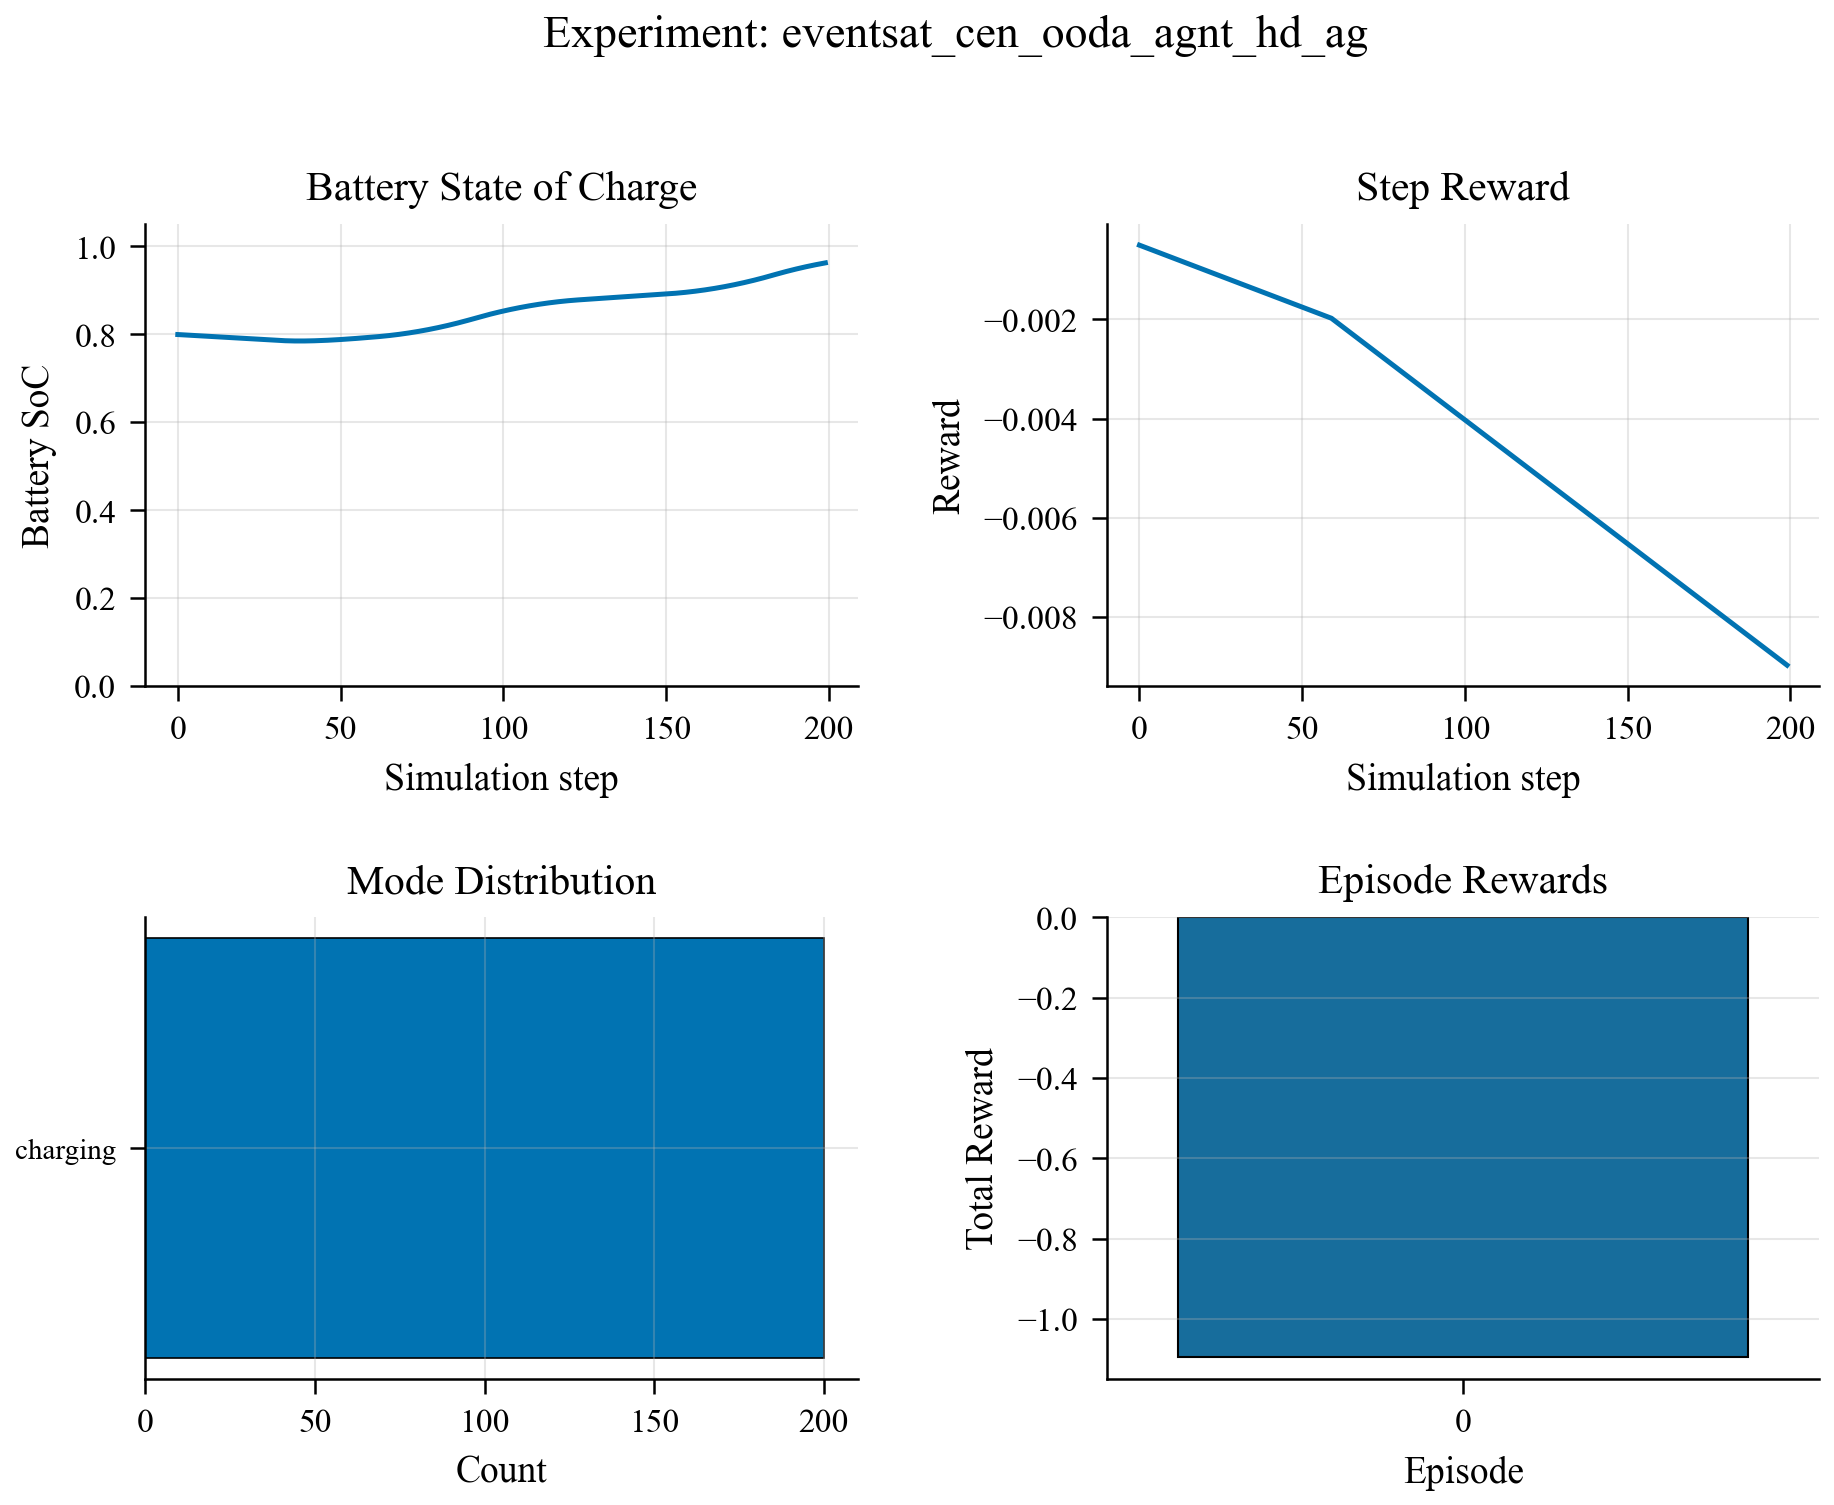

In [2]:
fig = plotting.plot_experiment_dashboard(step_df, episode_df)
fig.suptitle(f"Experiment: {raw['experiment_id']}", y=1.02, fontsize=11)
plt.show()

## 2. Time Series

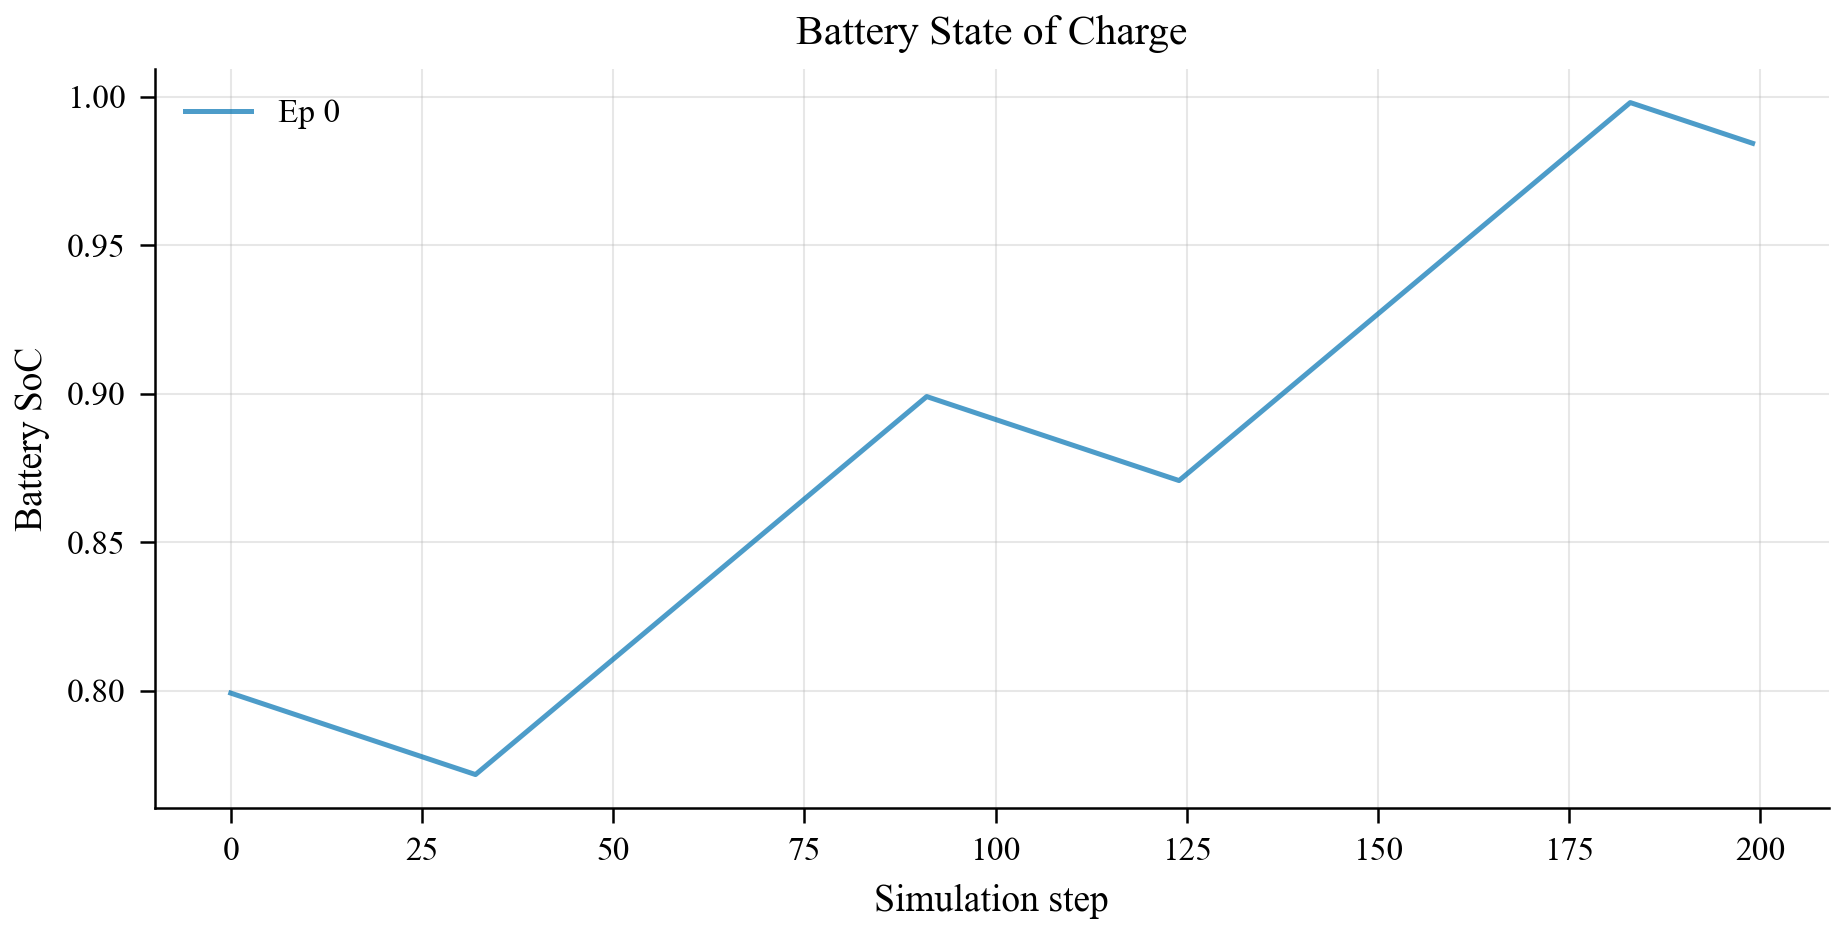

In [3]:
plotting.plot_timeseries(step_df, "battery_soc", ylabel="Battery SoC", title="Battery State of Charge")
plt.show()

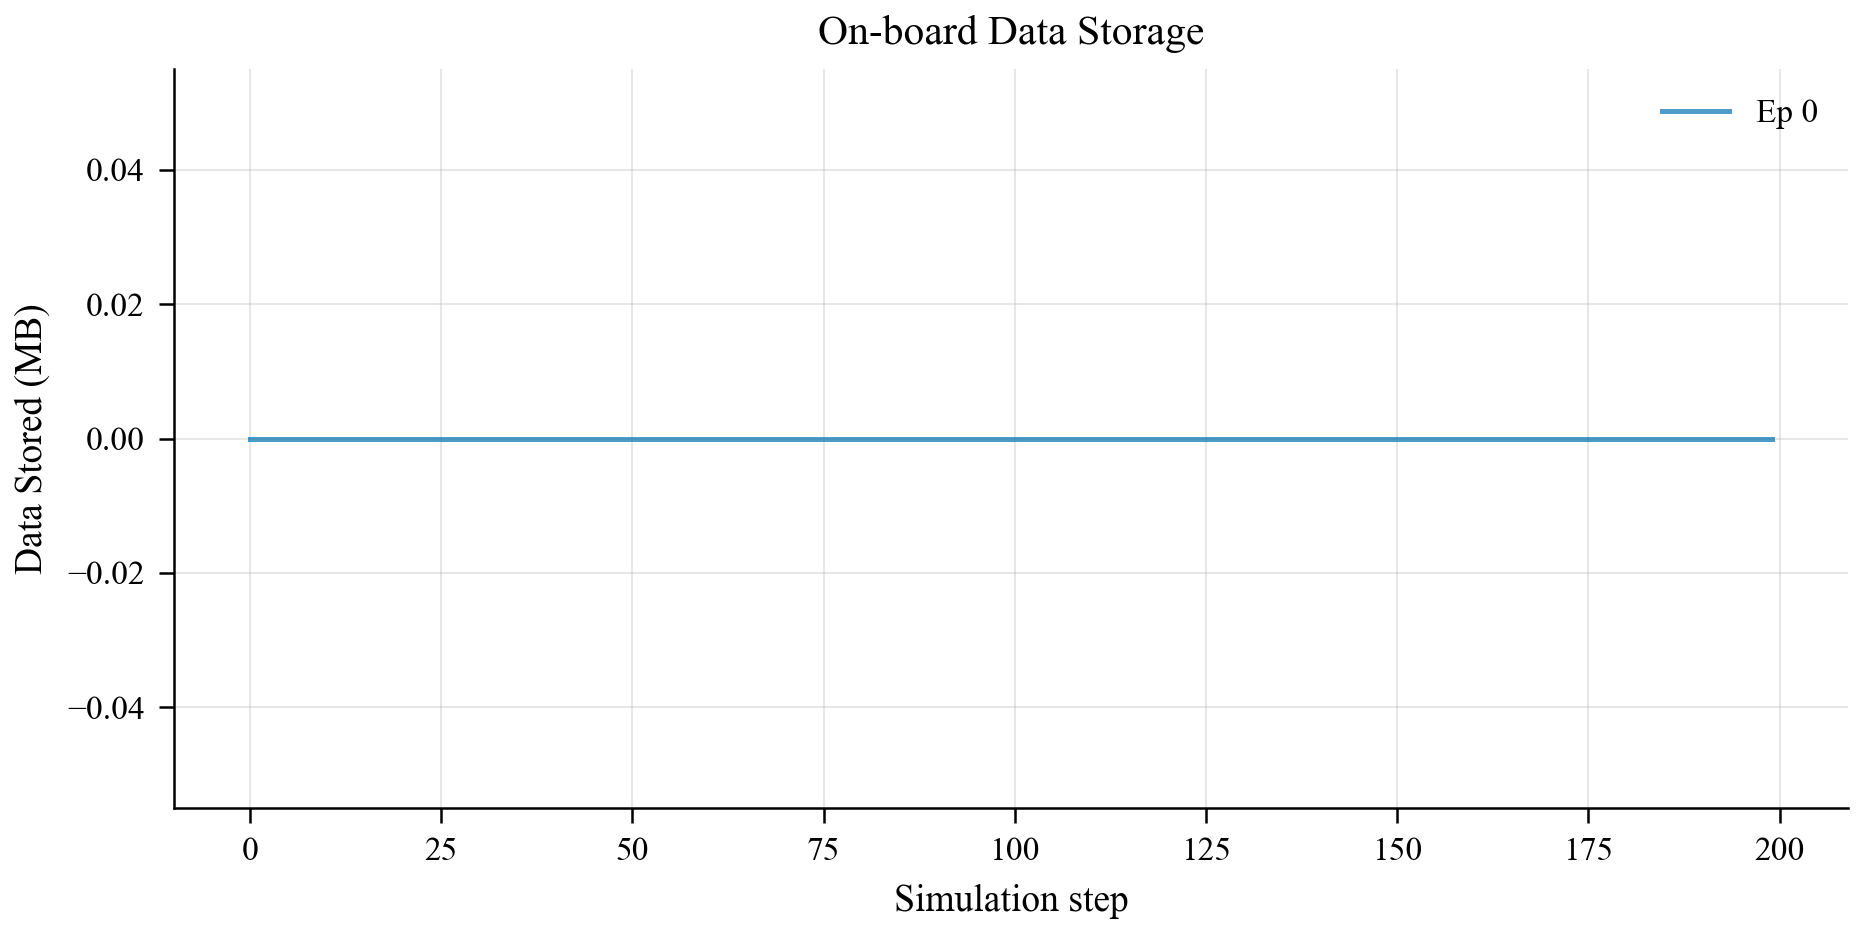

In [4]:
plotting.plot_timeseries(step_df, "data_stored_mb", ylabel="Data Stored (MB)", title="On-board Data Storage")
plt.show()

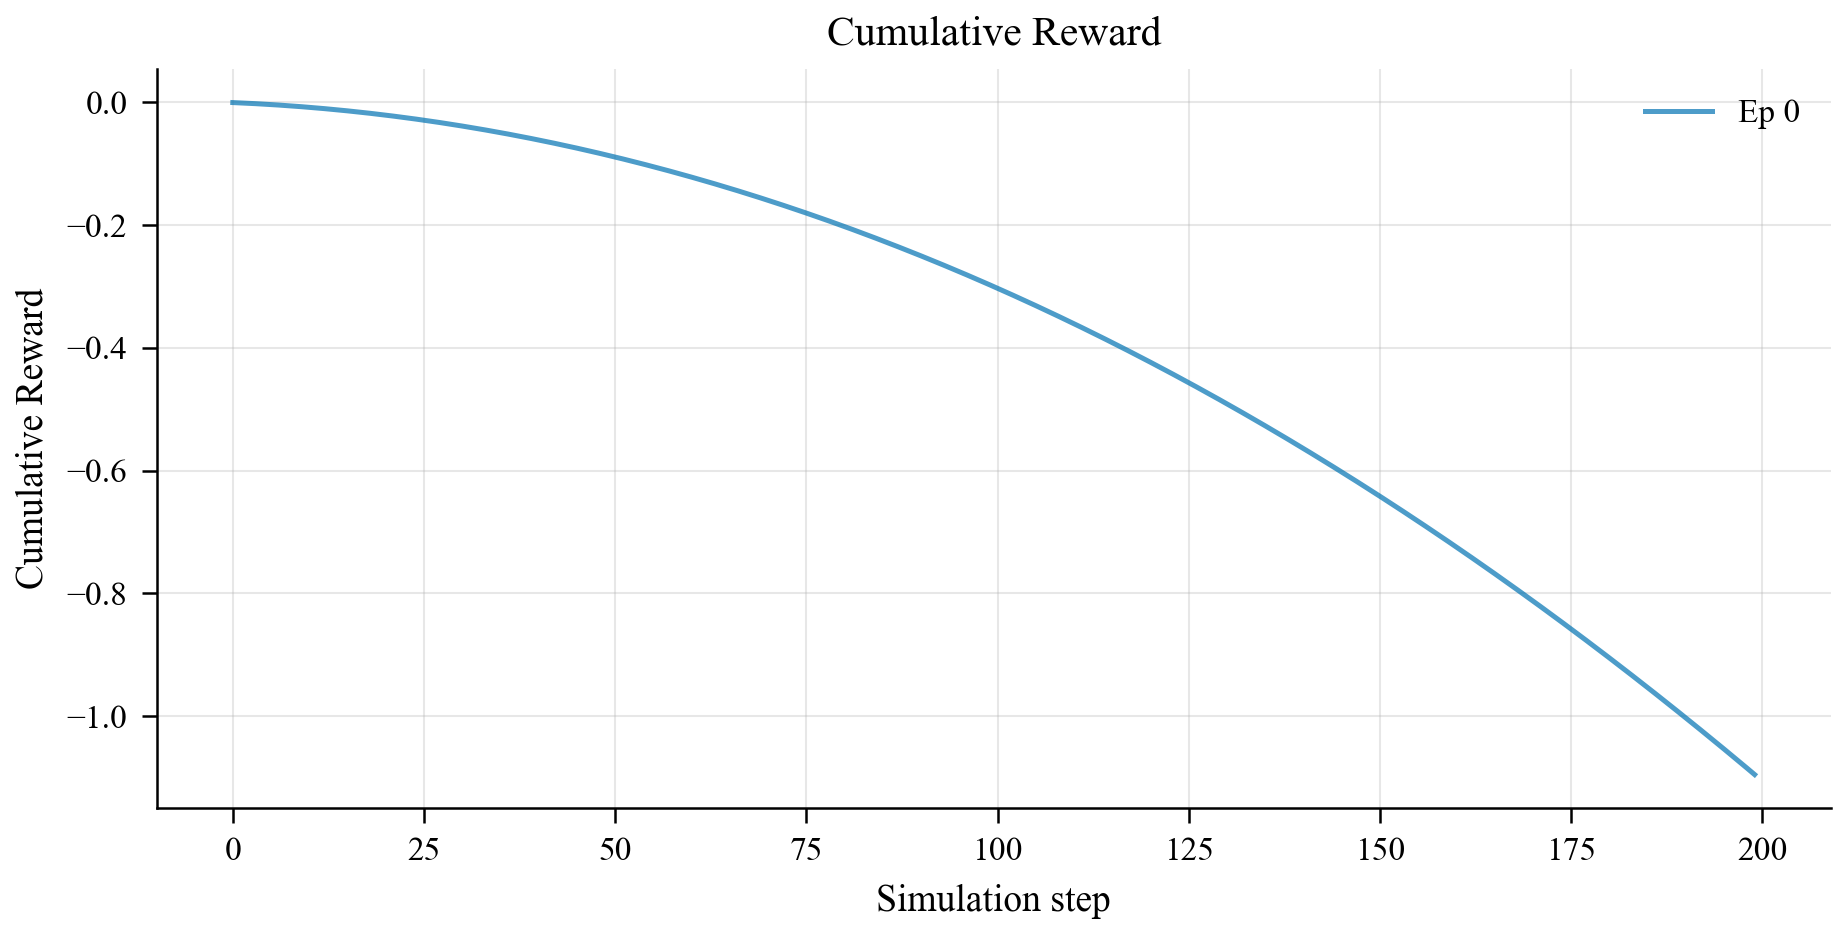

In [5]:
step_df["cumulative_reward"] = step_df.groupby("episode_id")["reward"].cumsum()
plotting.plot_timeseries(step_df, "cumulative_reward", ylabel="Cumulative Reward", title="Cumulative Reward")
plt.show()

## 3. Episode Summary

In [6]:
plotting.format_episode_summary(episode_df)

,Value
Metric,
Total Reward,-1.095
Mean Reward,-0.005
Observation (h),0.000
Downlinked (MB),0.000
Final Battery SoC,0.984
Final Data Stored (MB),0.000
Forced Mode Changes,0.000
Anomaly Events,0.000


## 4. Export

In [7]:
FIGS_DIR = ROOT / "data" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)

fig = plotting.plot_experiment_dashboard(step_df, episode_df, save_path=FIGS_DIR / "dashboard.pdf")
plt.close(fig)

ax = plotting.plot_timeseries(step_df, "battery_soc", ylabel="Battery SoC",
                              title="Battery State of Charge", save_path=FIGS_DIR / "battery_soc.pdf")
plt.close(ax.figure)

print(f"Figures saved to {FIGS_DIR}")

Figures saved to c:\Users\Clemente\autops-demo\data\figures
